Retrieving data and analyzing results from the file : /content/sensor_logs.csv
[SUCCESS] The image of the graph analysis results has been successfully saved at : ./plots/sensor_analysis_chart.png


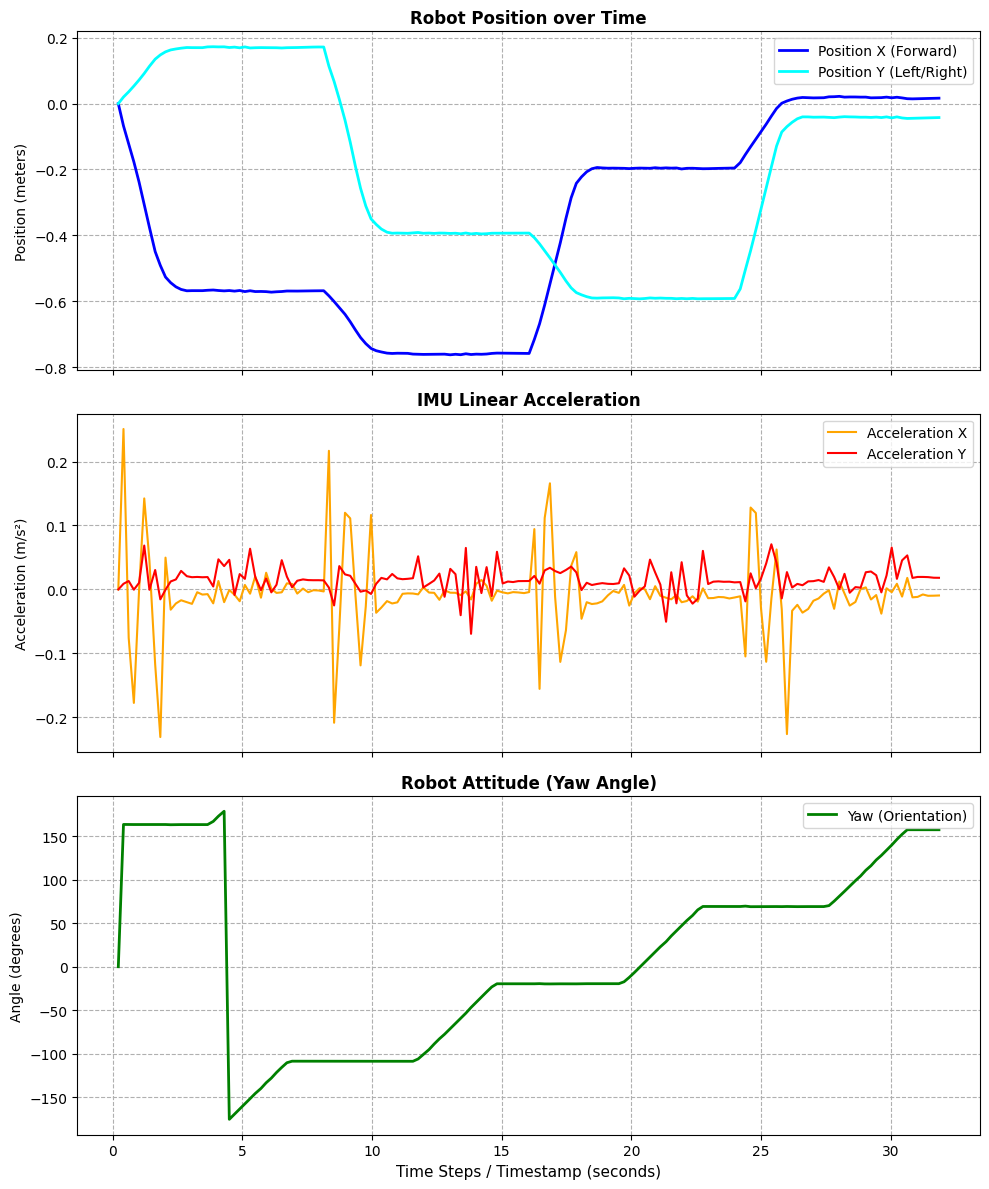

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# 1. import csv files
csv_files = glob.glob('/content/sensor_logs.csv')
if not csv_files:
    print("Run history log file not found. Please run the main script, main.py, first")
else:
    latest_file = max(csv_files, key=os.path.getctime)
    print(f"Retrieving data and analyzing results from the file : {latest_file}")

    df = pd.read_csv(latest_file)

    # 2. Configure plotting to display subplots in separate windows.
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Graph 1
    axes[0].plot(df['timestamp'], df['x'], label='Position X (Forward)', color='blue', linewidth=2)
    axes[0].plot(df['timestamp'], df['y'], label='Position Y (Left/Right)', color='cyan', linewidth=2)
    axes[0].set_title('Robot Position over Time', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Position (meters)', fontsize=10)
    axes[0].grid(True, linestyle='--')
    axes[0].legend()

    # Graph 2 : Measurement of the robot's angular acceleration using an IMU module
    axes[1].plot(df['timestamp'], df['acc_x'], label='Acceleration X', color='orange')
    axes[1].plot(df['timestamp'], df['acc_y'], label='Acceleration Y', color='red')
    axes[1].set_title('IMU Linear Acceleration', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Acceleration (m/s²)', fontsize=10)
    axes[1].grid(True, linestyle='--')
    axes[1].legend()

    # Graph 3 : Graph showing 90-degree turning behavior
    axes[2].plot(df['timestamp'], df['yaw'], label='Yaw (Orientation)', color='green', linewidth=2)
    axes[2].set_title('Robot Attitude (Yaw Angle)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Time Steps / Timestamp (seconds)', fontsize=11)
    axes[2].set_ylabel('Angle (degrees)', fontsize=10)
    axes[2].grid(True, linestyle='--')
    axes[2].legend()

    # Adjust the spacing, capture the graph image, and save it to a folder
    plt.tight_layout()
    plot_output_path = './plots/sensor_analysis_chart.png'
    os.makedirs('./plots', exist_ok=True)
    plt.savefig(plot_output_path, dpi=300)
    print(f"[SUCCESS] The image of the graph analysis results has been successfully saved at : {plot_output_path}")

    plt.show()